# Filter airports = (leave only EU airoports)
We use [Open airoports](https://ourairports.com/data/) dataset




PS allmost all the code is writen in module graph_craetion located in [github](https://github.com/sblenlkj/eu_flights). There you can find all the dat: csv, txt, md, json etc. To execute the code you should clone the repo and:
```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

This should work withoud installing the module in editable mode, however i did not check - i used uv and installed it


In [1]:
import pandas as pd
df = pd.read_csv("./data/raw/airports.csv")
df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [2]:
from graph_creation.config import get_our_countries
country_codes = get_our_countries()
country_codes_in_df = list(df['iso_country'].unique())

set(country_codes) - set(country_codes_in_df) # country codes are matched

set()

In [3]:
df['type'].unique() # we will use only 'small_airport', 'medium_airport', 'large_airport'

<StringArray>
[      'heliport',  'small_airport',  'seaplane_base',         'closed',
 'medium_airport',    'balloonport',  'large_airport']
Length: 7, dtype: str

In [4]:
df = df[['icao_code', 'name', 'type', 'iso_country', 'iso_region', 'municipality', 'latitude_deg', 'longitude_deg']]

only_eu_mask = df['iso_country'].apply(lambda x: x in country_codes)
only_aeroports_mask = df['type'].apply(lambda x: x in ['small_airport', 'medium_airport', 'large_airport'])
icao_code_exists_mask = ~df['icao_code'].isna()

mask = only_eu_mask & only_aeroports_mask & icao_code_exists_mask

eu_aeroports_df = df[mask]
eu_aeroports_df = eu_aeroports_df[~eu_aeroports_df['municipality'].isna()]
eu_aeroports_df.head()

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
12527,EBLB,Elsenborn Air Base,small_airport,BE,BE-WLG,Bütgenbach,50.484818,6.183014
12580,LBDM,Dve Mogili Airfield,small_airport,BG,BG-18,Dve Mogili,43.606541,25.890690
12592,LBBB,Belchinski Bani Airstrip,small_airport,BG,BG-23,Belchinski Bani,42.374713,23.392548
12594,LBBL,Blagoevo Airfield,small_airport,BG,BG-17,Blagoevo,43.455488,26.431655
12597,LBDR,Draganovtsi Airfield,small_airport,BG,BG-07,Draganovtsi,42.943042,25.169528


In [5]:
# We do not have airports in Liechtenstein
set(country_codes) - set(eu_aeroports_df['iso_country'].unique())

{'LI'}

In [6]:
len(eu_aeroports_df['iso_country'].unique()) # aeroports for 31 countries remains

32

In [7]:
eu_aeroports_df.isna().sum().sum()

np.int64(0)

In [8]:
eu_aeroports_df.shape

(1505, 8)

In [9]:
# cheating a bit :) 
# we do not use in the graph. This data should be learned from the graph itself
eu_aeroports_df['type'].value_counts()

type
small_airport     733
medium_airport    525
large_airport     247
Name: count, dtype: int64

We see that we have too many small airoports. They usually are military bases. Let's drop them

In [10]:
military_words = ["air base", "airfield"]
def check(name: str):
    name = name.lower()
    for word in military_words:
        if word in name:
            return True
    return False


not_military_mask = ~eu_aeroports_df["name"].apply(check)
eu_aeroports_df = eu_aeroports_df[not_military_mask]

In [11]:
# much better
eu_aeroports_df['type'].value_counts()

type
medium_airport    422
large_airport     247
small_airport     221
Name: count, dtype: int64

## Cleaning from military with the help of AI
Some military airports do not have "military" in the name. What a petty! We have to search for every airport in the internet, read its description and to decide to live it or not. We can use some "hacks":
- We will create graph first and will search for airoports in the graph. Some airports will not appear in in the graph, so we will not seracch for them.
- We will delegate this boring task to AI. 

What was done:
- I have parsed flights data and created a graph with nodes got above (the algorithm is below in the notebook), than i have collected airports codes (from nodes) in txt file
```python
with open("./data/raw/dirty_airports_codes.txt", "w") as f:
    for node in week_g.nodes:
        print(f"{node.id}: {''.join(node.airports)}", file=f)
```
- Chat GPT helped me to write the prompt (`./data/raw/prompts/clean_military_prompt.txt`). I send the prompt and the file with codes to Perplexity and got a json back (`./data/raw/airports_classification.json`).

In [12]:
import json 
dct = json.load(open("./data/raw/airports_classification.json"))
for k, v in dct.items():
    print(f"{k}: {len(v)}")

military_only: 11
joint_use: 11
civilian: 461
unknown: 0


In [13]:
# let's drop military_only from our potential nodes 
eu_aeroports_df = eu_aeroports_df[~eu_aeroports_df['icao_code'].isin(dct['military_only'])]
eu_aeroports_df.shape

(879, 8)

PS I have deleted the code, but i am quite happy with the result: ai cleaning allows us to get rid off 2 nodes - Carterton, Oxfordshire, GB (EGVN) and Laage, DE (ETNL). Theese nodes have many edges and a very strange connections pattern. Knowing that they are military explains this. 

However, Perplexity makes mistakes. For examlple, it stated that "LMML" in Valletta, Malta is a military base. The truth is that it is used to be but now it is the main civilian airport in the island.

## Paris, Istanbul, London, Bucharest problem
Paris, Istanbul, London, Bucharest have many airoports. In our df they are named differently (Le Touquet-Paris-Plage, Paris, Paris (Roissy-en-France, Val-d'Oise) etc). Let's rename to one singular name - Paris, Istanbul, London, Bucharest respectively - to get right aggregations by these cities

In [14]:
paris_mask = eu_aeroports_df['municipality'].apply(lambda x: "Paris" in x)
eu_aeroports_df[paris_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
43032,LFAT,Le Touquet-Côte d'Opale Airport,medium_airport,FR,FR-HDF,Le Touquet-Paris-Plage,50.518284,1.621656
43342,LFPB,Paris-Le Bourget International Airport,large_airport,FR,FR-IDF,Paris,48.962276,2.436539
43347,LFPG,Charles de Gaulle International Airport,large_airport,FR,FR-IDF,"Paris (Roissy-en-France, Val-d'Oise)",49.008960,2.554117
43354,LFPO,Paris-Orly Airport,large_airport,FR,FR-IDF,"Paris (Orly, Val-de-Marne)",48.723330,2.379440


In [15]:
eu_aeroports_df.loc[eu_aeroports_df[paris_mask].index, "municipality"] = "Paris"
eu_aeroports_df[paris_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
43032,LFAT,Le Touquet-Côte d'Opale Airport,medium_airport,FR,FR-HDF,Paris,50.518284,1.621656
43342,LFPB,Paris-Le Bourget International Airport,large_airport,FR,FR-IDF,Paris,48.962276,2.436539
43347,LFPG,Charles de Gaulle International Airport,large_airport,FR,FR-IDF,Paris,49.008960,2.554117
43354,LFPO,Paris-Orly Airport,large_airport,FR,FR-IDF,Paris,48.723330,2.379440


In [16]:
istanbul_mask = eu_aeroports_df['municipality'].apply(lambda x: "Istanbul" in x)
eu_aeroports_df[istanbul_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44398,LTBA,İstanbul Atatürk Airport,large_airport,TR,TR-34,Istanbul(Bakırköy),40.971913,28.823714
44453,LTFJ,Istanbul Sabiha Gökçen International Airport,large_airport,TR,TR-34,"Pendik, Istanbul",40.898602,29.309200
44455,LTFM,İstanbul Airport,large_airport,TR,TR-34,Istanbul,41.274874,28.732136


In [17]:
eu_aeroports_df.loc[eu_aeroports_df[istanbul_mask].index, "municipality"] = "Istanbul"
eu_aeroports_df[istanbul_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44398,LTBA,İstanbul Atatürk Airport,large_airport,TR,TR-34,Istanbul,40.971913,28.823714
44453,LTFJ,Istanbul Sabiha Gökçen International Airport,large_airport,TR,TR-34,Istanbul,40.898602,29.309200
44455,LTFM,İstanbul Airport,large_airport,TR,TR-34,Istanbul,41.274874,28.732136


In [18]:
london_mask = eu_aeroports_df['municipality'].apply(lambda x: "London" in x)
eu_aeroports_df[london_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
23922,EGKB,London Biggin Hill Airport,medium_airport,GB,GB-ENG,London,51.330799,0.032500
23926,EGKK,London Gatwick Airport,large_airport,GB,GB-ENG,London,51.148744,-0.185739
23930,EGLC,London City Airport,medium_airport,GB,GB-ENG,London,51.505299,0.055278
23935,EGLL,London Heathrow Airport,large_airport,GB,GB-ENG,London,51.470748,-0.459909
23946,EGML,Damyns Hall Aerodrome,small_airport,GB,GB-ENG,"Upminster, Greater London",51.527561,0.244189
23998,EGSG,Stapleford Aerodrome,small_airport,GB,GB-ENG,"Romford, Greater London",51.652500,0.155833
24008,EGSS,London Stansted Airport,large_airport,GB,GB-ENG,"London, Essex",51.884998,0.235000
24042,EGWU,RAF Northolt,medium_airport,GB,GB-ENG,"Northolt, Greater London",51.553001,-0.418167


In [19]:
eu_aeroports_df.loc[eu_aeroports_df[london_mask].index, "municipality"] = "London"
eu_aeroports_df[london_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
23922,EGKB,London Biggin Hill Airport,medium_airport,GB,GB-ENG,London,51.330799,0.032500
23926,EGKK,London Gatwick Airport,large_airport,GB,GB-ENG,London,51.148744,-0.185739
23930,EGLC,London City Airport,medium_airport,GB,GB-ENG,London,51.505299,0.055278
23935,EGLL,London Heathrow Airport,large_airport,GB,GB-ENG,London,51.470748,-0.459909
23946,EGML,Damyns Hall Aerodrome,small_airport,GB,GB-ENG,London,51.527561,0.244189
23998,EGSG,Stapleford Aerodrome,small_airport,GB,GB-ENG,London,51.652500,0.155833
24008,EGSS,London Stansted Airport,large_airport,GB,GB-ENG,London,51.884998,0.235000
24042,EGWU,RAF Northolt,medium_airport,GB,GB-ENG,London,51.553001,-0.418167


In [20]:
bucharest_mask = eu_aeroports_df['municipality'].apply(lambda x: "Otopeni" in x or "Bucharest" in x)
eu_aeroports_df[bucharest_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44144,LRBS,Bucharest Băneasa Aurel Vlaicu International A...,large_airport,RO,RO-B,Bucharest,44.503133,26.102944
44160,LROP,Bucharest Henri Coandă International Airport,large_airport,RO,RO-IF,Otopeni,44.571792,26.103285


In [21]:
eu_aeroports_df.loc[eu_aeroports_df[bucharest_mask].index, "municipality"] = "Bucharest"
eu_aeroports_df[bucharest_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44144,LRBS,Bucharest Băneasa Aurel Vlaicu International A...,large_airport,RO,RO-B,Bucharest,44.503133,26.102944
44160,LROP,Bucharest Henri Coandă International Airport,large_airport,RO,RO-IF,Bucharest,44.571792,26.103285


In [22]:
eu_aeroports_df.to_csv("./data/raw/eu_aeroports.csv", index=False)

## Airports to municipality aggregation
Several municipalities have more than one airport, lets aggregate them to municipality unit

In [23]:
# the same as eu_aeroports_df[['municipality']].value_counts().value_counts()
eu_aeroports_df.groupby('municipality')['icao_code'].count().value_counts()

icao_code
1    821
2     20
3      2
8      1
4      1
Name: count, dtype: int64

In [24]:
eu_aeroports_df[['municipality', 'iso_country']].value_counts().value_counts()

count
1    821
2     20
3      2
8      1
4      1
Name: count, dtype: int64

We do not have airoports with the same name located in different countries. Nevertheless we will use municipality name + country code as id. 

In [25]:
municipality_df = (
    eu_aeroports_df
    .groupby(["municipality", "iso_country"], as_index=False)
    .agg(
        icao_codes=("icao_code", list),
        iso_country=("iso_country", "first"),
        iso_region=("iso_region", "first"),
        latitude_deg=("latitude_deg", "mean"),
        longitude_deg=("longitude_deg", "mean"),
    )
)
municipality_df.head()

,municipality,icao_codes,iso_country,iso_region,latitude_deg,longitude_deg
0,Aachen,[EDKA],DE,DE-NW,50.823055,6.186389
1,Aalborg,[EKYT],DK,DK-81,57.094763,9.849930
2,Aarhus,[EKAH],DK,DK-82,56.303331,10.618286
3,Abbeyshrule,[EIAB],IE,IE-LD,53.591373,-7.642947
4,Aberdeen,[EGPD],GB,GB-SCT,57.201900,-2.197780


In [26]:
# drop brackets for airports
municipality_df['icao_codes'] = municipality_df['icao_codes'].apply(lambda x: ", ".join(x))
municipality_df.head()

,municipality,icao_codes,iso_country,iso_region,latitude_deg,longitude_deg
0,Aachen,EDKA,DE,DE-NW,50.823055,6.186389
1,Aalborg,EKYT,DK,DK-81,57.094763,9.849930
2,Aarhus,EKAH,DK,DK-82,56.303331,10.618286
3,Abbeyshrule,EIAB,IE,IE-LD,53.591373,-7.642947
4,Aberdeen,EGPD,GB,GB-SCT,57.201900,-2.197780


In [27]:
municipality_df.rename(columns={"icao_codes": "airports"}, inplace=True)

In [28]:
municipality_df.to_csv("./data/municipality.csv", index=False)

# Graph creation
We load flights data from OpenSKY provider. We collect data for one week: from 16 feb (mon) til 22 feb (sun). We can not load the whole week (400 error - too big timeframe), so we create one graph for 1 or 2 days, then we merge them into the whole week graph.

In [29]:
from graph_creation.bootstrap import bootsrap_create_save_graph_use_case
u = bootsrap_create_save_graph_use_case()

u.run("2026-02-16", day_interval_number=1, graph_name="2026-02-16")

loaded 108842 flights from OpenSky
flights with empty arr/dep = 33876
flights with empty icao or callsign = 39
unknown or non-eu departures: 58726
unknown or non-eu arrivals: 2217
self loops (flights within the same municipality): 905
not enough distance: 363
Graph created with 364 nodes and 4857 edges, flights: 12716


In [30]:
u.run("2026-02-17", day_interval_number=2, graph_name="2026-02-17_18")

loaded 225192 flights from OpenSky
flights with empty arr/dep = 70663
flights with empty icao or callsign = 108
unknown or non-eu departures: 125102
unknown or non-eu arrivals: 4481
self loops (flights within the same municipality): 2317
not enough distance: 830
Graph created with 416 nodes and 5351 edges, flights: 21691


In [31]:
u.run("2026-02-19", day_interval_number=2, graph_name="2026-02-19_20")

loaded 234369 flights from OpenSky
flights with empty arr/dep = 73382
flights with empty icao or callsign = 142
unknown or non-eu departures: 128499
unknown or non-eu arrivals: 4388
self loops (flights within the same municipality): 1884
not enough distance: 597
Graph created with 408 nodes and 6332 edges, flights: 25477


In [32]:
u.run("2026-02-21", day_interval_number=2, graph_name="2026-02-21_22")

loaded 218753 flights from OpenSky
flights with empty arr/dep = 69198
flights with empty icao or callsign = 113
unknown or non-eu departures: 118690
unknown or non-eu arrivals: 4067
self loops (flights within the same municipality): 1507
not enough distance: 638
Graph created with 401 nodes and 6254 edges, flights: 24540


In [32]:
from graph_creation.adapters.input import GraphJsonLoader
g1 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-16.json")
g2 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-17_18.json")
g3 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-19_20.json")
g4 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-21_22.json")

In [33]:
week_g = g1 + g2 + g3 + g4
week_g

Graph(type=DIRECTED, nodes=496, edges=9891, flights=84424, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [34]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
graph_to_pandas = GraphPandasAdapter(week_g)

nodes_df = graph_to_pandas.nodes_to_df()
nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,edges_count,node_degree,out_flights_number,in_flights_number
0,"Braunschweig, DE",Braunschweig,DE,DE-NI,52.319199,10.556100,EDVE,1,44,61,31,30
1,"Zgornji Brnik, SI",Zgornji Brnik,SI,SI-012,46.223701,14.457600,LJLJ,1,62,230,110,120
2,"Eindhoven, NL",Eindhoven,NL,NL-NB,51.450100,5.374530,EHEH,1,87,491,246,245
3,"Stockholm, SE",Stockholm,SE,SE-AB,59.501446,17.935265,"ESSA, ESSB",2,199,2719,1359,1360
4,"Constanța, RO",Constanța,RO,RO-CT,44.362202,28.488300,LRCK,1,8,15,8,7


In [ ]:
nodes_df.isna().sum()

id                    0
name                  0
iso_country           0
iso_region            0
latitude              0
longitude             0
airports              0
airports_count        0
edges_count           0
node_degree           0
out_flights_number    0
in_flights_number     0
dtype: int64

In [36]:
nodes_df['id'].value_counts().value_counts() # no node dupplicates, excellent (＊◕ᴗ◕＊)

count
1    496
Name: count, dtype: int64

In [6]:
nodes_df.to_csv("./data/graph_csv/nodes.csv", index=False)

In [7]:
edges_df = graph_to_pandas.edges_to_df()
edges_df.head()

,from_id,to_id,weight,distance
0,"Aalborg, DK","Billund, DK",2,156.52
1,"Aalborg, DK","Oslo (Gardermoen), NO",6,352.11
2,"Aalborg, DK","Copenhagen, DK",84,238.40
3,"Aalborg, DK","Amsterdam, NL",28,624.13
4,"Aalborg, DK","Málaga, ES",3,2507.05


In [8]:
edges_df.isna().sum().sum()

np.int64(0)

In [9]:
edges_df.to_csv("./data/graph_csv/edges.csv", index=False)

In [10]:
flights_df = graph_to_pandas.flights_to_df()
flights_df.head()

,icao,callsign,count
0,45d069,VKG4587,1
1,45884d,OYBBM,2
2,47875c,NOZ1259,1
3,4aca76,SAS99H,1
4,4aca74,SAS99H,1


In [11]:
flights_df.isna().sum().sum()

np.int64(0)

In [12]:
flights_df.to_csv("./data/graph_csv/flights.csv", index=False)

# Problem with directed graph: mooving to undirected
Flights go in/out of the arport so the graph is directed. But the directed graph:
- The main difficulty is that the **data was collected from free sources** - sometimes it is **not consistent**. Usually nodes have the same number for **in/out flights**, but sometimes it is not the case. For example, we have a node with only 2 flights out and and 137 in. It is Napoli, a large italian city. We do not want to drop it, instead we convert graph to undirected to preserve more real structure. 
- **For my ml experiments it is difficult to understand what's more important: in or out flights**. Imagine we have a flight that operates in a cycle A -> B -> C -> A. We do not study logistics, we experiment with the graph: for my ml experiments there is no meaningful difference between in/out flight. PS however, for graph analysis directed/underected is higly important but for our small experimental project based on FREE sources it is fine to convert. 

In [49]:
from graph_creation.adapters.input import GraphJsonLoader
directed_gr = GraphJsonLoader().load("./data/flights_week_graph.json")
directed_gr

Graph(type=DIRECTED, nodes=509, edges=9968, flights=84552, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

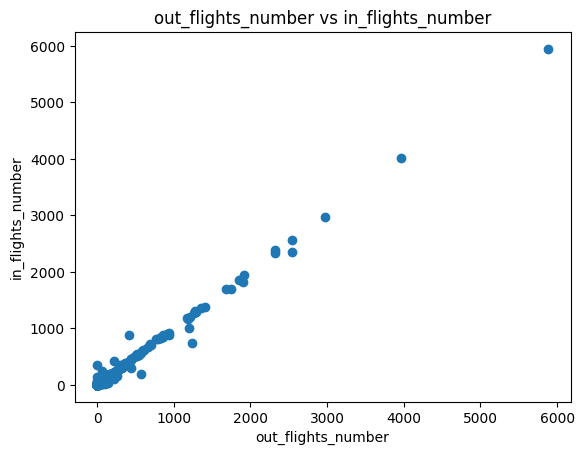

In [50]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
nodes_df = GraphPandasAdapter(directed_gr).nodes_to_df()

import matplotlib.pyplot as plt
plt.scatter(nodes_df['out_flights_number'], nodes_df['in_flights_number'])
plt.title('out_flights_number vs in_flights_number')
plt.xlabel('out_flights_number')
plt.ylabel('in_flights_number')
plt.show()

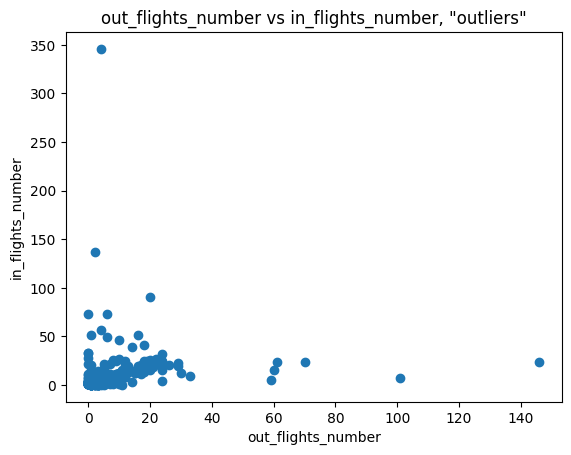

In [51]:
small_nodes_mask = (nodes_df['out_flights_number'] < 25) | (nodes_df['in_flights_number'] < 25)
small_nodes_df = nodes_df[small_nodes_mask]

plt.scatter(small_nodes_df['out_flights_number'], small_nodes_df['in_flights_number'])
plt.title('out_flights_number vs in_flights_number, "outliers"')
plt.xlabel('out_flights_number')
plt.ylabel('in_flights_number')
plt.show()

In [52]:
small_nodes_df[small_nodes_df['name'] == 'Napoli'][['id', 'in_flights_number', 'out_flights_number']]

,id,in_flights_number,out_flights_number
14,"Napoli, IT",137,2


In [53]:
# mooving to undirected
undirected_gr = directed_gr.to_undirected()
undirected_gr

Graph(type=UNDIRECTED, nodes=509, edges=6174, flights=84552, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

We used to have 9968 edges, now we have 6174 edges. The node number remains the same, 509. PS the algorithm is more difficult than in+out flights. The graph states that it was created by aggregating 84552 flights, but now if we summarise weights of undirected edges or nodes we will get less than 84552.

In [54]:
pa = GraphPandasAdapter(undirected_gr)
nodes_df = pa.nodes_to_df()
nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,edges_count,node_degree
0,"Tymbou (Kirklar), CY",Tymbou (Kirklar),CY,CY-02,35.153064,33.507352,LCEN,1,6,367
1,"Warsaw, PL",Warsaw,PL,PL-MZ,52.217449,20.937151,"EPBC, EPWA",2,102,2554
2,"Saint-Nazaire/Montoir, FR",Saint-Nazaire/Montoir,FR,FR-PDL,47.311420,-2.152634,LFRZ,1,4,30
3,"Skellefteå, SE",Skellefteå,SE,SE-AC,64.624802,21.076900,ESNS,1,5,55
4,"Memmingen, DE",Memmingen,DE,DE-BY,47.988092,10.238248,EDJA,1,40,158


## Prunning nodes with too small degree (< 3)

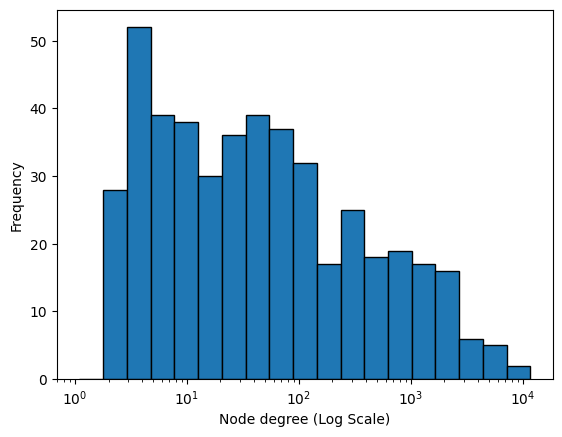

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def hist(data: pd.Series):
    bins = np.logspace(np.log10(min(data)+0.1), np.log10(max(data)), 20)
    _, ax = plt.subplots()

    ax.hist(data, bins=bins, edgecolor='black')

    ax.set_xscale('log')
    ax.set_xlabel('Node degree (Log Scale)')
    ax.set_ylabel('Frequency')
    plt.show()

hist(nodes_df['node_degree'])

In [56]:
nodes_df['node_degree'].value_counts()

node_degree
1       53
3       36
2       28
5       17
4       16
        ..
5919     1
4708     1
301      1
32       1
58       1
Name: count, Length: 218, dtype: int64

Let's conduct a light filter - remove nodes with degree < 3. Removing a node means removing all its edges and decreasing the the degree of another node. So a node with degree 3 can become a node with degree 2. Therefore we do removing in cycle.

In [5]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
from graph_creation.domain.graph import Graph

def drop_nodes_by_treshold(gr: Graph, threshold: int = 3, by: str = 'node_degree') -> tuple[Graph, list[str]]:
    deleted_nodes = []
    undirected_after_prunning_gr = gr.copy()

    while True:
        nodes_after_prunning_df = GraphPandasAdapter(undirected_after_prunning_gr).nodes_to_df()
        too_small_mask = nodes_after_prunning_df[by] < threshold
        ids_to_delete = nodes_after_prunning_df[too_small_mask]['id'].values
        deleted_nodes.extend(ids_to_delete)

        if len(ids_to_delete) == 0:
            break

        undirected_after_prunning_gr.drop_nodes(ids_to_delete)
        print(f"deleted {len(ids_to_delete)} nodes")
    
    return undirected_after_prunning_gr, deleted_nodes

deleted 81 nodes
deleted 3 nodes


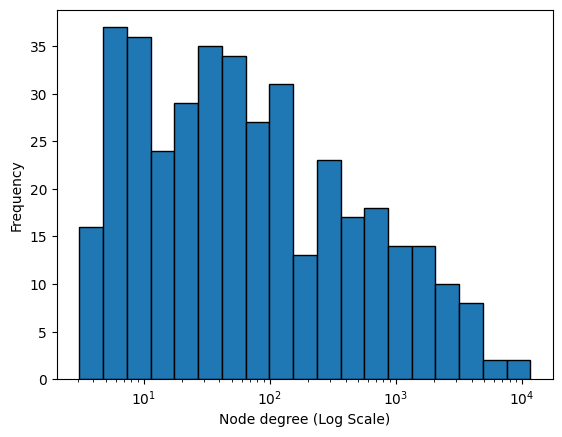

In [58]:
undirected_after_prunning_gr, deleted_nodes = drop_nodes_by_treshold(undirected_gr, threshold=3)
new_nodes_df = GraphPandasAdapter(undirected_after_prunning_gr).nodes_to_df()
hist(new_nodes_df['node_degree'])

In [59]:
undirected_after_prunning_gr

Graph(type=UNDIRECTED, nodes=425, edges=6071, flights=84439, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [60]:
def get_drops_stats_df(nodes_df: pd.DataFrame, deleted_nodes: list[str]):
    """return df with dropped nodes stats per country"""
    # total nodes per country
    deleted_nodes_df = nodes_df[nodes_df['id'].isin(deleted_nodes)]
    total_by_country = (
        nodes_df.groupby('iso_country', dropna=False)['id']
        .count()
        .rename('total_nodes')
    )

    # dropped nodes per country
    dropped_by_country = (
        deleted_nodes_df.groupby('iso_country', dropna=False)['id']
        .count()
        .rename('dropped_nodes')
    )

    # merge + metrics
    drop_stats_df = (
        pd.concat([total_by_country, dropped_by_country], axis=1)
        .fillna(0)
        .assign(
            dropped_nodes=lambda df: df['dropped_nodes'].astype(int),
            kept_nodes=lambda df: df['total_nodes'] - df['dropped_nodes'],
            dropped_pct=lambda df: (100 * df['dropped_nodes'] / df['total_nodes']).round(2),
        )
        .sort_values(['dropped_pct', 'dropped_nodes', 'total_nodes'], ascending=[False, False, False])
        .reset_index()
        .rename(columns={'iso_country': 'country'})
    )

    return drop_stats_df[drop_stats_df['dropped_pct'] > 0]

In [61]:
get_drops_stats_df(nodes_df, deleted_nodes)

,country,total_nodes,dropped_nodes,kept_nodes,dropped_pct
0,BG,3,2,1,66.67
1,CZ,11,5,6,45.45
2,SE,32,10,22,31.25
3,TR,16,5,11,31.25
4,GR,18,5,13,27.78
5,FI,17,4,13,23.53
6,NL,9,2,7,22.22
7,GB,63,13,50,20.63
8,IE,10,2,8,20.00
9,HR,5,1,4,20.00


In [62]:
from graph_creation.adapters.output import GraphJsonExporter
GraphJsonExporter("data").export(undirected_after_prunning_gr, "flights_week_graph_undirected_after_prunning.json")

# Setting labels for nodes = classification on panel data
One of the my ml experiment is to predict whether the node (airport or group of airports in one municipality, remember about aggregation) is large, medium or small. For this we need to set labels for nodes.
## From dataset
Our dataset with nodes contains this labels for airports. Let's use them.

In [93]:
from graph_creation.adapters.input import GraphJsonLoader
undirected_gr = GraphJsonLoader().load("./data/flights_week_graph_undirected_after_prunning.json")
undirected_gr

Graph(type=UNDIRECTED, nodes=425, edges=6071, flights=84439, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [94]:
import pandas as pd
airports_df = pd.read_csv("./data/raw/airports.csv")
airports_df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [95]:
airport_tupe_dct = {}
for row in airports_df.iterrows():
    if isinstance(row[1]["icao_code"], str):
        airport_tupe_dct[row[1]["icao_code"]] = row[1]["type"]

undirected_gr.populate_node_types(airport_tupe_dct)

Counter({'medium': 198, 'large': 195, 'small': 32})

In [262]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
nodes_df = GraphPandasAdapter(undirected_gr).nodes_to_df()
nodes_df['node_type'].isna().sum() # we have set node_type, no more nans

np.int64(0)

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def degree_by_label_boxplots(data: pd.DataFrame):
    hue_order = ["small", "medium", "large"]

    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=data,
        x="node_degree",
        y="node_type",
        order=hue_order
    )
    plt.xscale("log")
    plt.title("Node degree by node type")
    plt.xlabel("Node degree (log scale)")
    plt.ylabel("Node type")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

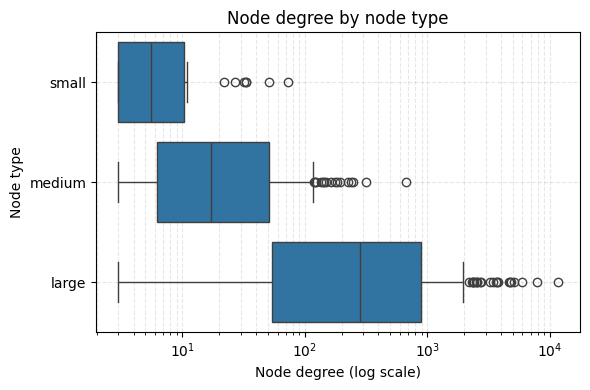

In [98]:
degree_by_label_boxplots(nodes_df)

Looks bad: the tendency is visible but huge amount of outliers / noise due to:
- Free data. For some airports that are large we colected only a small portion of the traffic
- Wrong labeling from free community dataset: some airports that are operated only by small civilian planes are labeled as "large".

Let's create our own labelings

## By chat gpt
We will send our airports codes to chatgpt. The prompt can be found in `./data/raw/prompts/split_airports.md`. The result can be found in `./data/raw/airports_classification_gpt_v2.json` - the v1 also exists but v2 was cleaned from dupplicates by myself and google search

In [185]:
from graph_creation.adapters.input import GraphJsonLoader
undirected_gr = GraphJsonLoader().load("./data/flights_week_graph_undirected_after_prunning.json")
undirected_gr

Graph(type=UNDIRECTED, nodes=425, edges=6071, flights=84439, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [186]:
import json
type_airports_dct = json.load(open("./data/raw/airports_classification_gpt_v2.json"))
airport_tupe_dct = {}

for k, v in type_airports_dct.items():
    for airport in v:
        airport_tupe_dct[airport] = k

undirected_gr.populate_node_types(airport_tupe_dct)

Counter({'medium': 194, 'small': 153, 'large': 78})

In [187]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
nodes_df = GraphPandasAdapter(undirected_gr).nodes_to_df()
nodes_df.isna().sum().loc['node_type'] # we have set node_type, no more nans

np.int64(0)

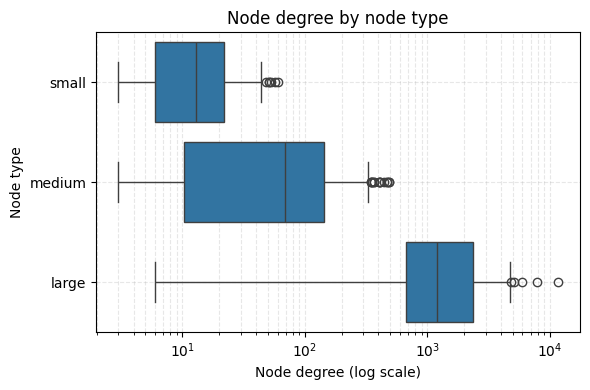

In [188]:
degree_by_label_boxplots(nodes_df)

Better but outliers due to free data: for some large airports we have aggregated a little part of the trafic. Let's delete them!

In [189]:
from graph_creation.domain.graph import Graph

def clean_graph_from_noise(gr: Graph, medium_treshold=20, large_treshold=300, threshold=3):
    def get_nodes_to_drop(nodes_df: pd.DataFrame):
        medium_bad_mask = (nodes_df['node_type'] == 'medium') & (nodes_df['node_degree'] < medium_treshold)
        large_bad_mask = (nodes_df['node_type'] == 'large') & (nodes_df['node_degree'] < large_treshold)

        bad_medium_nodes = nodes_df[medium_bad_mask]
        bad_large_nodes = nodes_df[large_bad_mask]

        return bad_medium_nodes['id'].tolist() + bad_large_nodes['id'].tolist()

    gr_copy = gr.copy()
    droped_lst = []

    while True:
        new_nodes_df = GraphPandasAdapter(gr_copy).nodes_to_df()
        bad_nodes = get_nodes_to_drop(new_nodes_df)

        if len(bad_nodes) == 0:
            break

        gr_copy.drop_nodes(bad_nodes)
        droped_lst.extend(bad_nodes)

        final_gr, deleted_nodes = drop_nodes_by_treshold(gr_copy, threshold=threshold)
        droped_lst.extend(deleted_nodes)
        gr_copy = final_gr

    return gr_copy, droped_lst

gr_for_label_prediction, droped_lst1 = clean_graph_from_noise(undirected_gr, medium_treshold=30, large_treshold=500)
final_graph, droped_lst2 = clean_graph_from_noise(undirected_gr, medium_treshold=10, large_treshold=100)

deleted 3 nodes
deleted 2 nodes


In [190]:
final_graph

Graph(type=UNDIRECTED, nodes=371, edges=5862, flights=84115, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [191]:
final_graph.node_types

Counter({'small': 151, 'medium': 144, 'large': 76})

In [192]:
get_drops_stats_df(nodes_df, droped_lst2) # we get rid off Bulgaria :(

,country,total_nodes,dropped_nodes,kept_nodes,dropped_pct
0,BG,1,1,0,100.00
1,FI,13,5,8,38.46
2,FR,71,22,49,30.99
3,DK,8,2,6,25.00
4,HR,4,1,3,25.00
5,SK,4,1,3,25.00
6,IT,41,8,33,19.51
7,SE,22,4,18,18.18
8,RO,8,1,7,12.50
9,ES,35,3,32,8.57


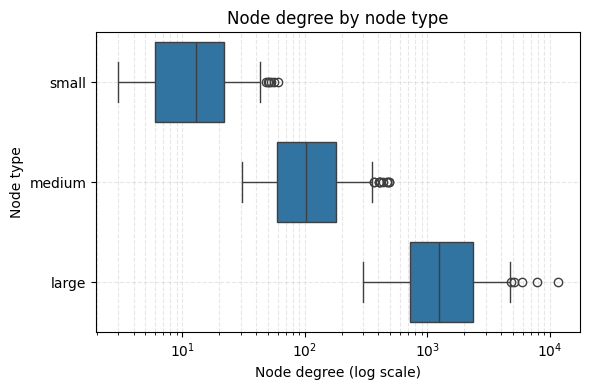

In [193]:
nodes_final_df = GraphPandasAdapter(final_graph).nodes_to_df()
degree_by_label_boxplots(nodes_final_df)

Beautiful, workable!

In [194]:
gr_for_label_prediction

Graph(type=UNDIRECTED, nodes=368, edges=5766, flights=83454, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [195]:
gr_for_label_prediction.node_types

Counter({'small': 150, 'medium': 144, 'large': 74})

In [196]:
get_drops_stats_df(nodes_df, droped_lst1)

,country,total_nodes,dropped_nodes,kept_nodes,dropped_pct
0,BG,1,1,0,100.00
1,FI,13,5,8,38.46
2,FR,71,22,49,30.99
3,DK,8,2,6,25.00
4,HR,4,1,3,25.00
5,SK,4,1,3,25.00
6,IT,41,8,33,19.51
7,SE,22,4,18,18.18
8,IE,8,1,7,12.50
9,RO,8,1,7,12.50


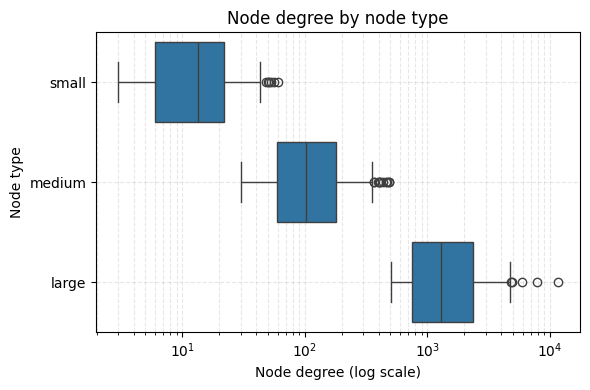

In [197]:
nodes_for_label_df = GraphPandasAdapter(gr_for_label_prediction).nodes_to_df()
degree_by_label_boxplots(nodes_for_label_df)

Splitting into 2 graphs was unnecesary: they differ only by one node. This is an artifact of my previus sad attempts to work with labels from dataset without chatgpt rearrangements

In [29]:
from graph_creation.adapters.output import GraphJsonExporter
from graph_creation.domain.graph import Graph

def save_the_graph(gr: Graph, gr_name: str, path_to_graphs_folder: str = "./final_graphs_data"):
    GraphJsonExporter(f"{path_to_graphs_folder}/{gr_name}").export(gr, gr_name)
    pa = GraphPandasAdapter(gr)
    pa.nodes_to_df().to_csv(f"{path_to_graphs_folder}/{gr_name}/nodes.csv", index=False)
    pa.edges_to_df().to_csv(f"{path_to_graphs_folder}/{gr_name}/edges.csv", index=False)

In [ ]:
save_the_graph(final_graph, "final_graph")
save_the_graph(gr_for_label_prediction, "gr_for_label_prediction")

# Setting NUTS3 codes for nodes = regression on panel data
*I call them "nut3" codes because i have made an error and did not want to correct everywhere word "nuts"*

Load nuts3 PPS data from eurostat and prepare the graph.   
Gross domestic product (GDP) at current market prices by NUTS 3 region, [eurostat](https://ec.europa.eu/eurostat/databrowser/view/nama_10r_3gdp__custom_16402140/bookmark/table?lang=en&bookmarkId=3edea12e-d6ab-46cd-ab3e-d547d9bae3c1&c=1745826708191). We can load data with eurostat API. 

Our final table contains 3 columns:
- nut3_code
- pps, in millions of points
- pps per inhabitant, points

In [92]:
from graph_creation.adapters.input.pps_from_eurostat_loader import load_nuts3_gdp
pps_df = load_nuts3_gdp()
pps_df.head()

unit,nut3_code,pps,pps_per_inhabitant
0,AT,436203.37,47500.0
1,AT1,188494.63,46600.0
2,AT11,10384.18,34400.0
3,AT12,67871.36,39300.0
4,AT13,110239.09,54600.0


The file above do not have data for Great Britan, Norway, Switzerland. We should drop them

In [93]:
from graph_creation.adapters.input.graph_json_loader import GraphJsonLoader
gr_for_nuts3 = GraphJsonLoader().load("./final_graphs_data/gr_for_label_prediction/gr_for_label_prediction.json")
gr_for_nuts3

Graph(type=UNDIRECTED, nodes=314, edges=5421, flights=82549, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [94]:
gr_for_nuts3.drop_countries(["NO", "CH", "GB"])
gr_for_nuts3

Graph(type=UNDIRECTED, nodes=251, edges=3663, flights=52212, countries=27, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [95]:
ready_gr_for_nuts3, _ = drop_nodes_by_treshold(gr_for_nuts3)
ready_gr_for_nuts3

deleted 4 nodes


Graph(type=UNDIRECTED, nodes=247, edges=3660, flights=52208, countries=27, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [96]:
import json 

nuts3_dct = {}
data_lst = json.load(open("./data/nodes_with_nuts_codes.json"))
for node_data in data_lst:
    nuts3_dct[node_data["id"]] = node_data["nuts3_code"]

for node in ready_gr_for_nuts3.nodes:
    node.nut3_code = nuts3_dct[node.id]

Problem: we have fewer codes in our nuts3 to pps mapping than we have in our graph. We have to make codes shorter = to increase the nut3 sector size. PS for some countries even till the country level. 

In [97]:
import pandas as pd

k, country_codes_set = 0, set()
for node in ready_gr_for_nuts3.nodes:
    code = node.nut3_code

    if code is None:
        continue

    while code not in pps_df['nut3_code'].values:
        if len(code) == 2:
            k += 1
            country_codes_set.add(node.nut3_code)
            break
        code = code[:-1]
    else:
        node.nut3_code = code

print(k, country_codes_set)

0 set()


In [98]:
dct = {}
for n in ready_gr_for_nuts3.nodes:
    dct[n.nut3_code] = dct.get(n.nut3_code, 0) + 1

from collections import Counter
Counter(dct.values()) # Ussualy one city = one code

Counter({1: 157, 2: 25, 3: 9, 4: 2, 5: 1})

In [101]:
save_the_graph(ready_gr_for_nuts3, "ready_gr_for_nuts3")
nuts3_in_use = set(n.nut3_code for n in ready_gr_for_nuts3.nodes)
pps_df[pps_df["nut3_code"].isin(nuts3_in_use)].to_csv("./final_graphs_data/ready_gr_for_nuts3/nuts3_in_use_pps.csv", index=False)

Now we are fine

# Edges embedings = our last seminars anout dl for graphs
For almost every flight we have 2 codes: icao and callsign. From icas we can get a plane model, callsign - company. Then we can aggregate them into groups and get embeddings for edges.

In [30]:
from graph_creation.adapters.input import GraphJsonLoader
from graph_creation.adapters.output.graph.pandas_adapter import GraphPandasAdapter

gr_for_edges_embeddings = GraphJsonLoader().load("./final_graphs_data/gr_for_label_prediction/gr_for_label_prediction.json")
pa = GraphPandasAdapter(gr_for_edges_embeddings)
gr_for_edges_embeddings

Graph(type=UNDIRECTED, nodes=368, edges=5766, flights=83454, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [31]:
threshold = 20

edges_df = pa.edges_to_df()
mask = edges_df['weight'] > threshold

lst = []
for row in edges_df[mask].iterrows():
    lst.append([row[1]['id1'], row[1]['id2']])

gr_for_edges_embeddings.filter_edges(lst)

Graph(type=UNDIRECTED, nodes=179, edges=989, flights=61723, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [32]:
pa.nodes_to_df()

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,edges_count,node_type,node_degree
0,"Tymbou (Kirklar), CY",Tymbou (Kirklar),CY,CY-02,35.153064,33.507352,LCEN,1,2,medium,331
1,"Warsaw, PL",Warsaw,PL,PL-MZ,52.217449,20.937151,"EPBC, EPWA",2,42,large,2160
2,"Skellefteå, SE",Skellefteå,SE,SE-AC,64.624802,21.076900,ESNS,1,1,medium,51
3,"Pisa (PI), IT",Pisa (PI),IT,IT-52,43.683899,10.392700,LIRP,1,1,medium,59
4,"Akrotiri, CY",Akrotiri,CY,CY-XX,34.590401,32.987900,LCRA,1,1,small,29
...,...,...,...,...,...,...,...,...,...,...,...
174,"Bodø, NO",Bodø,NO,NO-18,67.269203,14.365300,ENBO,1,2,medium,269
175,"Bodrum, TR",Bodrum,TR,TR-48,37.194706,27.666856,"LTBV, LTFE",2,1,medium,61
176,"Amsterdam, NL",Amsterdam,NL,NL-NH,52.308601,4.763890,EHAM,1,80,large,5528
177,"Frankfurt am Main, DE",Frankfurt am Main,DE,DE-HE,50.026706,8.558350,EDDF,1,63,large,4401


In [33]:
gr_for_edges_embeddings_ready, _ = drop_nodes_by_treshold(gr_for_edges_embeddings, threshold=3, by="edges_count")
gr_for_edges_embeddings_ready

deleted 78 nodes


Graph(type=UNDIRECTED, nodes=101, edges=894, flights=57069, countries=29, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [34]:
from graph_creation.adapters.output import FoliumMapExporter
FoliumMapExporter().export(gr_for_edges_embeddings_ready, "gr_for_edges_embeddings")

## Get plane model from icao

In [35]:
pa = GraphPandasAdapter(gr_for_edges_embeddings_ready)
flights_df = pa.flights_to_df()
flights_df.head()

,icao,callsign,count
0,4785c2,WIF9Y,1
1,4aca79,SAS4616,1
2,4aca79,SAS4612,1
3,4785bf,WIF369,2
4,4aca75,SAS4612,1


In [36]:
import json
import numpy as np
import pandas as pd

def load_adsbx_db(path: str):
    by_icao = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            icao = rec.get("icao")
            if not icao:
                continue

            by_icao[icao.strip().lower()] = rec

    return by_icao


def lookup_aircraft_fields(
    icao_hex: str,
    db: dict
):
    key = icao_hex.strip().lower()
    rec = db.get(key)
    if rec is None:
        return [icao_hex, None]
    return [icao_hex, rec.get("model")]

db = load_adsbx_db("./data/raw/basic-ac-db.json")
nan, not_nan = 0, 0
lst = []
for flight_icao in flights_df['icao'].unique():
    res = lookup_aircraft_fields(flight_icao, db)
    lst.append(res)

models_from_json_df = pd.DataFrame(lst, columns=["icao", "model"])
models_from_json_df['model'] = models_from_json_df['model'].apply(lambda x: x if x != "" else np.nan)
models_from_json_df.dropna(inplace=True)
models_from_json_df['model'] = models_from_json_df['model'].apply(lambda x: x.strip())
models_from_json_df.head()

,icao,model
0,4785c2,Bombardier DHC-8-Q-402
2,4785bf,Bombardier DHC-8-Q-402NG
9,478d83,Bombardier DHC-8 402 NG
11,478f0e,Bombardier DHC-8-Q-402NG
12,4aca76,ERJ-190-200


In [37]:
icao_df = pd.read_csv("./data/raw/aircraft_database_complete.csv", on_bad_lines='skip')[["'icao24'", "'model'"]]
icao_df.head()

icao_df.rename(columns={"'icao24'": "icao", "'model'": "model"}, inplace=True)
icao_df['icao'] = icao_df['icao'].apply(lambda x: x.strip("'"))

icao_df = icao_df[~icao_df['model'].isna() & ~icao_df['icao'].isna()]

check = lambda x: x != "''"
icao_df = icao_df[icao_df['model'].apply(check)]

icao_df['model'] = icao_df['model'].apply(lambda x: x.strip("' "))
icao_list = list(flights_df['icao'].unique())
my_icao_df = pd.DataFrame(data=[[i] for i in icao_list], columns=["icao"])

models_from_csv_df = my_icao_df.merge(icao_df, on="icao", how="left", suffixes=("", "_ref"))
models_from_csv_df.dropna(inplace=True)
models_from_csv_df.head()

/var/folders/9t/1ptzvr3n0hj_46m1tt2qrqqh0000gn/T/ipykernel_10658/1135425065.py:1: DtypeWarning: Columns (0: 'acars', 1: 'adsb', 2: 'built', 3: 'firstSeen', 4: 'modes', 5: 'regUntil') have mixed types. Specify dtype option on import or set low_memory=False.
  icao_df = pd.read_csv("./data/raw/aircraft_database_complete.csv", on_bad_lines='skip')[["'icao24'", "'model'"]]


,icao,model
0,4785c2,DHC-8 402 NG
2,4785bf,DHC-8 402 NG
3,4aca75,Embraer E195LR
5,4aca70,Embraer E195LR
6,478ef4,De Havilland Canada Dash 8-400


In [38]:
import pandas as pd
icaos = models_from_json_df['icao'].unique()
models_from_csv_mask = models_from_csv_df['icao'].apply(lambda x: x not in icaos)
models_df = pd.concat([models_from_json_df, models_from_csv_df[models_from_csv_mask]], axis=0, ignore_index=True)
flights_df = flights_df.merge(models_df, on="icao", how="left")
flights_df.head()

,icao,callsign,count,model
0,4785c2,WIF9Y,1,Bombardier DHC-8-Q-402
1,4aca79,SAS4616,1,NaN
2,4aca79,SAS4612,1,NaN
3,4785bf,WIF369,2,Bombardier DHC-8-Q-402NG
4,4aca75,SAS4612,1,Embraer E195LR


In [39]:
gr_for_edges_embeddings_ready

Graph(type=UNDIRECTED, nodes=101, edges=894, flights=57069, countries=29, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [40]:
def clean_model(x: str):
    if isinstance(x, float):
        return x
    dct = {
        "737": "Boeing 737",
        "747": "Boeing 747",
        "777": "Boeing 777",
        "787": "Boeing 787",
        "767": "Boeing 767",
        "220": "Airbus A220",
        "300": "Airbus A300",
        "320": "Airbus A320",
        "321": "Airbus A321",
        "319": "Airbus A319",
        "330": "Airbus A330",
        "bombardier": "Bombardier",
        "cessna": "Cessna",
        "falcon": "Falcon", 
        "embraer": "Embraer",
        "gulfstream": "Gulfstream",
    }
    x_copy = x.lower()
    for k in dct:
        if k in x_copy:
            return dct[k]

    return x


flights_df['model'] = flights_df['model'].apply(clean_model)
flights_df.head()

,icao,callsign,count,model
0,4785c2,WIF9Y,1,Bombardier
1,4aca79,SAS4616,1,NaN
2,4aca79,SAS4612,1,NaN
3,4785bf,WIF369,2,Bombardier
4,4aca75,SAS4612,1,Embraer


In [41]:
lst = json.load(open("./data/embedings_from_model.json"))
aggregated_lst = []
for g in lst:
    aggregated_lst.extend(g['models'])


def func(x):
    if isinstance(x, float):
        return "nan"
    if x in aggregated_lst:
        return "good"
    return "not aggregated"

flights_df['in_grouping'] = flights_df['model'].apply(func)
flights_df.groupby('in_grouping').agg({'icao': 'count'})

,icao
in_grouping,
good,40922
nan,6721
not aggregated,2473


In [42]:
dct = {}
for row in flights_df.iterrows():
    if row[1]['model'] is not None:
        dct[row[1]['icao']] = row[1]['model']

for e in gr_for_edges_embeddings_ready.edges:
    for f in e.flights:
        f.flight.model = dct.get(f.flight.icao, None)

## Get company from callsign
Each flight has a callsign. The first 3 letters of the callsign usually indicate the air company. We can extract these codes and create a mapping from code to air company name.

In [43]:
uniqs_callsign = flights_df['callsign'].unique().tolist()
air_company_codes = list(set([callsign[:3] for callsign in uniqs_callsign if callsign[:3].isalpha()]))
print(f"{len(air_company_codes)} air company codes found")

482 air company codes found


In [44]:
with open("./data/companies.txt", "w", encoding="utf-8") as f:
    for s in air_company_codes:
        print(s, file=f)

In [45]:
lst = json.load(open("./data/embedings_from_callsign.json"))
aggregated_lst = []
for g in lst:
    aggregated_lst.extend(g['models'])

def check_callsign(x: str):
    if isinstance(x, float):
        return "nan"
    if x[:3] in aggregated_lst:
        return "good"
    return "not aggregated"


flights_df['in_grouping_callsign'] = flights_df['callsign'].apply(check_callsign)
flights_df.groupby('in_grouping_callsign').agg({'icao': 'count'})

,icao
in_grouping_callsign,
good,42451
not aggregated,7665


## Check embedings

In [46]:
from graph_creation.domain.graph import Embedding
import json 

callsign_embeddings = [Embedding(dct["group_name"], dct["models"]) for dct in json.load(open("./data/embedings_from_callsign.json"))]
model_embeddings = [Embedding(dct["group_name"], dct["models"]) for dct in json.load(open("./data/embedings_from_model.json"))] 

_ = gr_for_edges_embeddings_ready.create_edge_embeddings(callsign_embeddings, model_embeddings, assign_to_edges=True)

In [47]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
pa = GraphPandasAdapter(gr_for_edges_embeddings_ready)
edges_df = pa.edges_to_df(with_embeddings=True)
edges_df.head()

,id1,id2,weight,distance,pct_lufthansa_group,pct_air_france_klm_group,pct_iag_group,pct_nordic_legacy,pct_mediterranean_legacy,pct_turkish_and_south_east_legacy,...,pct_other_specialized,pct_narrowbody_airbus,pct_narrowbody_boeing,pct_widebody,pct_regional,pct_business_jet,operator_coverage,aircraft_coverage,log_total_flights,log_unique_callsigns
0,"Aberdeen, GB","Stavanger, NO",35,497.01,0.0,0.0,0.0,1.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.542857,0.485714,3.583519,2.197225
1,"Aberdeen, GB","London, GB",135,648.13,0.0,0.0,0.0,0.0,0.0,0.0,...,0.791045,1.0,0.000000,0.0,0.000000,0.0,0.992593,0.866667,4.912655,3.465736
2,"Aberdeen, GB","Amsterdam, NL",55,703.27,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.232558,0.0,0.767442,0.0,1.000000,0.781818,4.025352,2.397895
3,"Aberdeen, GB","Bergen, NO",22,548.27,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.000000,0.454545,3.135494,1.945910
4,"Aberdeen, GB","Dublin, IE",24,491.91,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.0,0.000000,0.0,1.000000,0.0,0.416667,0.083333,3.218876,1.791759


In [48]:
edges_df.iloc[:, 3:].mean()

distance                             1047.032192
pct_lufthansa_group                     0.147720
pct_air_france_klm_group                0.085177
pct_iag_group                           0.048440
pct_nordic_legacy                       0.106439
pct_mediterranean_legacy                0.035125
pct_turkish_and_south_east_legacy       0.071529
pct_ryanair_group                       0.177552
pct_easyjet_group                       0.114303
pct_wizz_group                          0.023506
pct_other_low_cost_leisure              0.087424
pct_cargo                               0.028857
pct_other_specialized                   0.043728
pct_narrowbody_airbus                   0.537787
pct_narrowbody_boeing                   0.242516
pct_widebody                            0.038854
pct_regional                            0.157925
pct_business_jet                        0.010614
operator_coverage                       0.822143
aircraft_coverage                       0.801444
log_total_flights   

In [49]:
edges_df.to_csv("./data/edges_embeddings_ready.csv", index=False)

In [50]:
save_the_graph(gr_for_edges_embeddings_ready, "gr_for_edges_embeddings_ready")

In [51]:
gr_for_edges_embeddings_ready.edges[0].embeddings

[0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.5428571428571428,
 0.4857142857142857,
 3.58351893845611,
 2.1972245773362196]